In [1]:
# pip install kagglehub[pandas-datasets]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [3]:
# Original source: samartalwar/sleep-debt-and-screen-time-late-night-phone-habits on Kaggle.
# Analysis uses the saved CSV below; no download or overwrite is needed.


In [4]:
# load from csv, assuming the file is data/bedtime_screentime_sleep_debt.csv

df = pd.read_csv("data/bedtime_screentime_sleep_debt.csv")

In [5]:
df.describe()

,age,bedtime_phone_minutes,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,34.355647,59.250000,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209,21.735741,19.105859,2.766000,3.794671
std,11.584259,36.931991,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258,3.069377,2.546459,1.695407,2.685153
min,18.000000,1.000000,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000,8.100000,9.600000,0.000000,1.000000
25%,25.000000,31.000000,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000,19.700000,17.400000,2.000000,1.100000
50%,32.000000,51.000000,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000,21.900000,19.100000,3.000000,3.200000
75%,42.000000,79.000000,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000,23.900000,20.800000,4.000000,5.600000
max,65.000000,180.000000,100.000000,1.000000,250.000000,112.000000,123.300000,9.800000,28.000000,27.000000,7.000000,10.000000


In [6]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation_type', 'chronotype',
       'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct',
       'blue_light_filter_active', 'caffeine_post_5pm_mg',
       'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours',
       'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes',
       'next_day_fatigue_score', 'sleep_debt_category'],
      dtype='object')

In [7]:
df['occupation_type'].unique()

array(['Healthcare / Shift Worker', 'Student', 'Remote Tech',
       'Freelance / Creative', 'Corporate 9-to-5'], dtype=object)

In [8]:
df['primary_bedtime_app'].unique()

array(['Instagram / Reddit', 'YouTube', 'TikTok / Reels',
       'News / Reading', 'Streaming (Netflix/Hulu)', 'Messaging / Chat'],
      dtype=object)

## Phone -> Sleep -> Fatigue
How are late-night phone habits associated with sleep quality, and how do those sleep differences relate to next-day fatigue?

## What Makes Doomscrolling Worse?
If someone spends a long time on their phone before bed, what other behaviors are associated with making the sleep penalty larger or smaller?

We'll start by investigating a relationship between screen time and REM Sleep

In [9]:
# Investigating the relationship between REM sleep and screen time
rem = df['rem_sleep_pct'] 
bed_minutes = df['bedtime_phone_minutes']

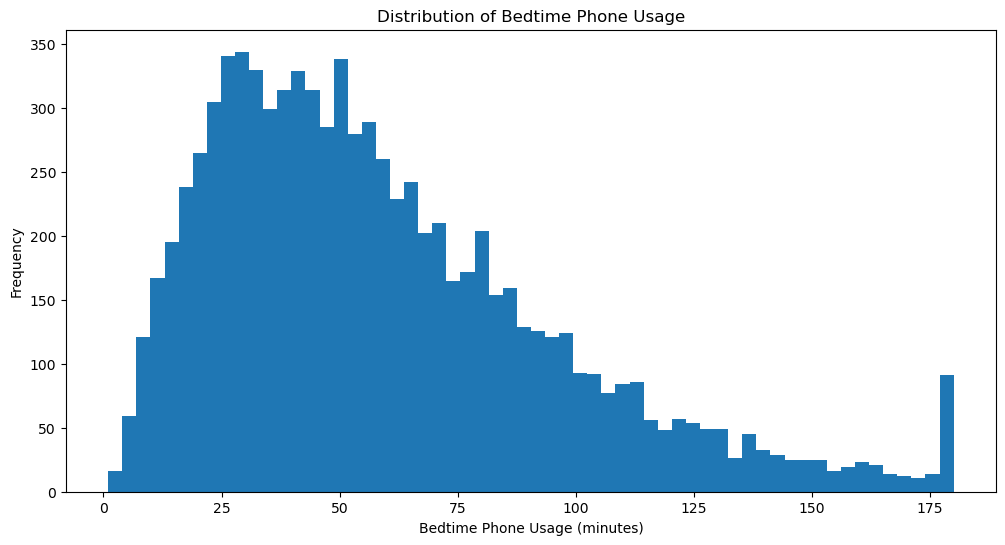

In [10]:

# Creating a histogram for bedtime phone usage
plt.figure(figsize=(12, 6))
plt.hist(bed_minutes, bins=60)
plt.xlabel('Bedtime Phone Usage (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Bedtime Phone Usage')
plt.show()

More people tend to use up to an hour of their phone in bed.

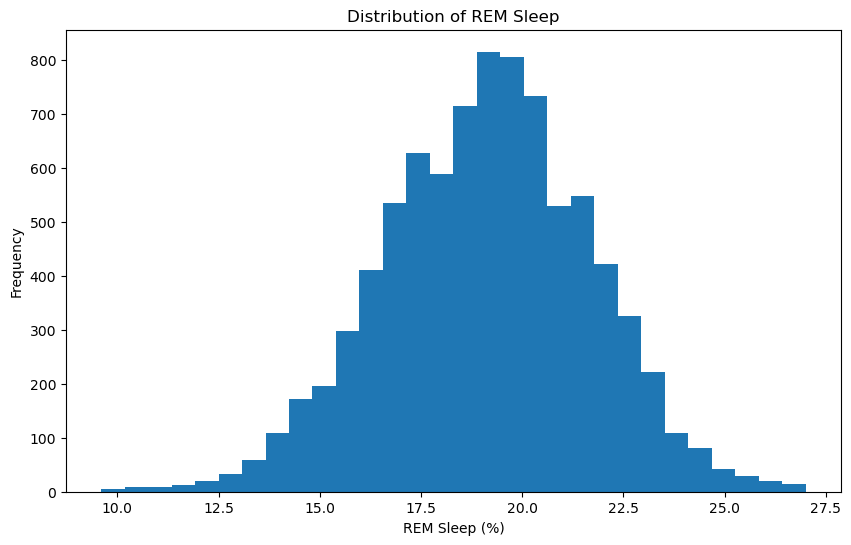

In [11]:
# Creating a histogram for REM sleep
plt.figure(figsize=(10, 6))
plt.hist(rem, bins=30)
plt.xlabel('REM Sleep (%)')
plt.ylabel('Frequency')
plt.title('Distribution of REM Sleep')
plt.show()


People tend to get around 15-22.5% REM Sleep.

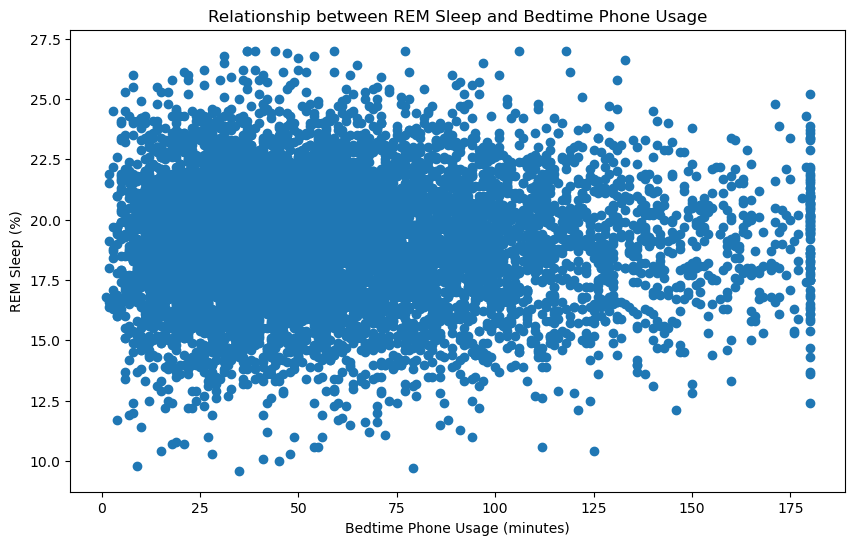

<Figure size 1000x600 with 0 Axes>

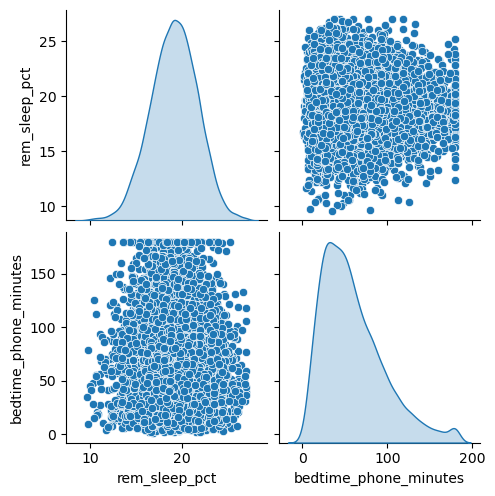

In [12]:
# Investigating relationship between REM sleep and bedtime phone usage through different types of plots
plt.figure(figsize=(10, 6))
plt.scatter(bed_minutes, rem)
plt.xlabel('Bedtime Phone Usage (minutes)')
plt.ylabel('REM Sleep (%)')
plt.title('Relationship between REM Sleep and Bedtime Phone Usage')
plt.show()

# Creating a pairplot for REM sleep and bedtime phone usage
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.pairplot(df[['rem_sleep_pct', 'bedtime_phone_minutes']], diag_kind='kde')
plt.show()

### Testing whether other behaviors change the screen-time penalty

The histograms describe the sample; the screen-time–REM scatter addresses the starting
association. Predictor-versus-predictor plots help inspect exposure patterns but do not
answer whether the REM slope changes. A **screen-time interaction** tests that slope change.

We retain `rem`, `bed_minutes`, `brightness`, `blue_light_filter`, `caffeine`, and `app`
from the exploration above. The outcome remains **REM percentage**, so an effect of -1
means one percentage point less REM, not one minute or a 1% relative decrease. A change
in REM percentage need not imply the same change in REM duration.

Each model adjusts for brightness, filter status, evening caffeine, app choice, physical
activity, age, gender, occupation, and chronotype. Interaction models add one interaction
at a time to the same baseline. This is exploratory association analysis, not evidence
that changing a behavior causes a change in sleep. Bedtime clock time, total daily screen
time, and sampling/provenance details are not available in the CSV.

In [44]:
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from patsy import build_design_matrices
from IPython.display import display

brightness = df['screen_brightness_pct']
blue_light_filter = df['blue_light_filter_active']
caffeine = df['caffeine_post_5pm_mg']

# Reuse the Series already created above; use one complete-case sample for every model.
rem_analysis = df.assign(
    rem_pct=rem, screen_30=bed_minutes / 30,
    brightness_25=(brightness - 50) / 25,
    filter_on=blue_light_filter, caffeine_100=caffeine / 100,
    bedtime_app=app)
rem_columns = ['rem_pct', 'screen_30', 'brightness_25', 'filter_on', 'caffeine_100',
               'bedtime_app', 'physical_activity_min', 'age', 'gender', 'occupation_type', 'chronotype']
rem_analysis = rem_analysis[rem_columns].dropna().copy()
assert df.loc[rem_analysis.index, 'user_id'].is_unique, 'Repeated users require clustered inference.'
print(f'Analyzing {len(rem_analysis):,} of {len(df):,} rows; {len(df) - len(rem_analysis)} excluded for missing values.')
print('Filter values:', sorted(rem_analysis.filter_on.unique()))
assert set(rem_analysis.filter_on.unique()) <= {0, 1}
rem_main_formula = ('rem_pct ~ screen_30 + brightness_25 + filter_on + caffeine_100 + '
                    'C(bedtime_app) + physical_activity_min + age + C(gender) + '
                    'C(occupation_type) + C(chronotype)')
rem_models, rem_interpretations, rem_interaction_tests = {}, {}, {}

# A fixed typical profile makes the line plots comparable; only the displayed exposures vary.
rem_profile = rem_analysis.iloc[[0]].copy()
for column in rem_columns:
    rem_profile[column] = (rem_analysis[column].median() if pd.api.types.is_numeric_dtype(rem_analysis[column])
                           else rem_analysis[column].mode().iloc[0])
rem_profile['filter_on'] = 0

def rem_design(model, frame):
    return np.asarray(build_design_matrices([model.model.data.design_info], frame)[0])

def rem_slope_vector(model, settings):
    low = rem_profile.assign(screen_30=2, **settings)
    high = rem_profile.assign(screen_30=3, **settings)
    return (rem_design(model, high) - rem_design(model, low))[0]

def rem_contrast(model, vector):
    test = model.t_test(vector)
    low, high = np.asarray(test.conf_int()).ravel()
    return {'REM pp per +30 min': float(np.asarray(test.effect).item()),
            '95% CI lower': float(low), '95% CI upper': float(high),
            'p-value': float(np.asarray(test.pvalue).item())}

def rem_slope_table(model, scenarios):
    return pd.DataFrame({label: rem_contrast(model, rem_slope_vector(model, settings))
                         for label, settings in scenarios.items()}).T

def rem_interaction_test(model, key):
    terms = [i for i, name in enumerate(model.params.index) if ':' in name]
    restriction = np.eye(len(model.params))[terms]
    result = model.wald_test(restriction, use_f=True, scalar=True)
    p = float(result.pvalue)
    rem_interaction_tests[key] = {'interaction p-value': p, 'adjusted R2': model.rsquared_adj}
    return p

def rem_lines(model, scenarios, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, settings in scenarios.items():
        grid = pd.concat([rem_profile] * 80, ignore_index=True)
        grid['screen_30'] = np.linspace(rem_analysis.screen_30.min(), rem_analysis.screen_30.max(), 80)
        for column, value in settings.items():
            grid[column] = value
        prediction = model.get_prediction(grid).summary_frame()
        x = grid.screen_30.to_numpy() * 30
        line, = ax.plot(x, prediction['mean'], label=label)
        ax.fill_between(x, prediction['mean_ci_lower'], prediction['mean_ci_upper'], alpha=0.10, color=line.get_color())
    ax.set(xlabel='Bedtime phone use (minutes)', ylabel='Predicted REM sleep (%)', title=title)
    ax.legend(title='Other covariates fixed at the same typical profile')
    plt.tight_layout()
    plt.show()

def rem_effect_sentence(result):
    return (f"{result['REM pp per +30 min']:+.3f} REM percentage points "
            f"(95% CI {result['95% CI lower']:+.3f} to {result['95% CI upper']:+.3f})")

Analyzing 8,500 of 8,500 rows; 0 excluded for missing values.
Filter values: [np.int64(0), np.int64(1)]


### Screen time → REM sleep

First estimate the unadjusted association, then the adjusted baseline that the following
four models share. All intervals use HC3 heteroskedasticity-robust standard errors.

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Unadjusted,-0.0177,-0.0613,0.0259,0.4262
Adjusted,-0.0146,-0.0520,0.0228,0.4437


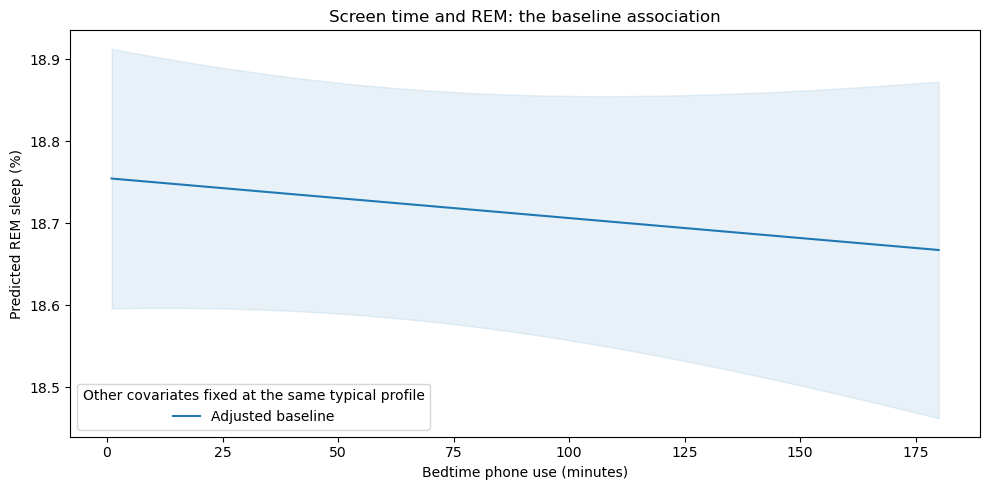

In [39]:
rem_unadjusted = smf.ols('rem_pct ~ screen_30', data=rem_analysis).fit(cov_type='HC3')
rem_baseline = smf.ols(rem_main_formula, data=rem_analysis).fit(cov_type='HC3')
rem_models['baseline'] = rem_baseline
rem_baseline_results = pd.DataFrame({
    'Unadjusted': rem_contrast(rem_unadjusted, rem_slope_vector(rem_unadjusted, {})),
    'Adjusted': rem_contrast(rem_baseline, rem_slope_vector(rem_baseline, {}))}).T
display(rem_baseline_results.round(4))
rem_lines(rem_baseline, {'Adjusted baseline': {}}, 'Screen time and REM: the baseline association')
baseline_effect = rem_baseline_results.loc['Adjusted'].to_dict()
rem_interpretations['baseline'] = (
    '**Outcome:** Each additional 30 minutes of phone use is associated with '
    + rem_effect_sentence(baseline_effect) + ', holding the listed factors constant. '
    'The unadjusted row shows how the estimate changes after adjustment. '
    'This is the starting screen-time penalty; it assumes the same slope for everyone. '
    'The interaction models below ask whether that slope varies, rather than merely whether '
    'one group has a lower overall REM level. Shading in the plots represents a 95% confidence '
    'interval for the fitted mean, not the spread of individual sleep outcomes.')

**Outcome:** Each additional 30 minutes of phone use is associated with -0.015 REM percentage points (95% CI -0.052 to +0.023), holding the listed factors constant. The unadjusted row shows how the estimate changes after adjustment. The interval includes zero, so there is no clear adjusted screen-time association with REM percentage here. Calling this a REM-percentage penalty would overstate the evidence. This baseline assumes the same slope for everyone. The interaction models below ask whether that slope varies, rather than merely whether one group has a lower overall REM level. Shading in the plots represents a 95% confidence interval for the fitted mean, not the spread of individual sleep outcomes.

### Screen time × brightness → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
25% brightness,-0.0036,-0.0710,0.0638,0.9158
50% brightness,-0.0128,-0.0514,0.0257,0.5142
75% brightness,-0.0220,-0.0749,0.0309,0.4147


,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Slope change per +25 brightness percentage points,-0.0092,-0.0559,0.0376,0.7001


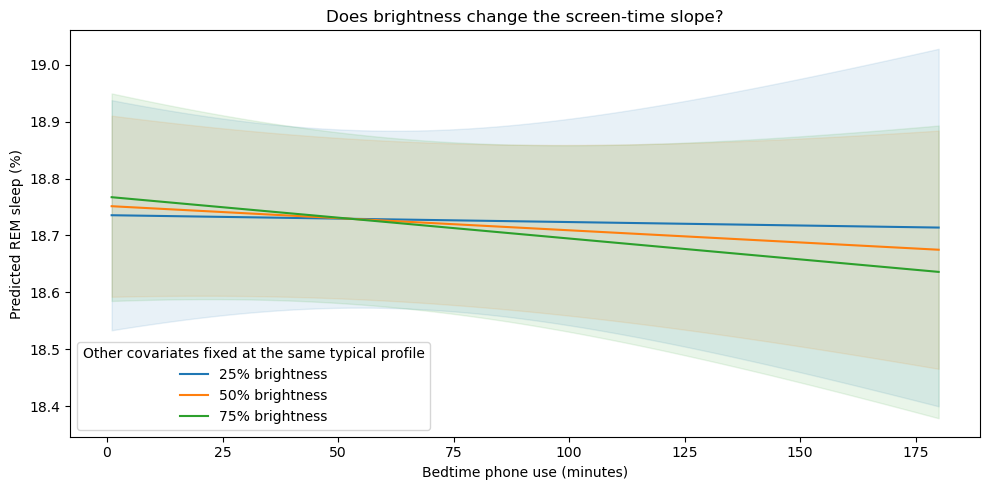

In [41]:
rem_brightness_model = smf.ols(rem_main_formula + ' + screen_30:brightness_25', data=rem_analysis).fit(cov_type='HC3')
rem_models['brightness'] = rem_brightness_model
brightness_scenarios = {'25% brightness': {'brightness_25': -1},
                        '50% brightness': {'brightness_25': 0},
                        '75% brightness': {'brightness_25': 1}}
display(rem_slope_table(rem_brightness_model, brightness_scenarios).round(4))
brightness_difference = rem_contrast(rem_brightness_model,
    rem_slope_vector(rem_brightness_model, {'brightness_25': 1}) -
    rem_slope_vector(rem_brightness_model, {'brightness_25': 0}))
display(pd.DataFrame([brightness_difference], index=['Slope change per +25 brightness percentage points']).round(4))
rem_interaction_test(rem_brightness_model, 'brightness')
rem_lines(rem_brightness_model, brightness_scenarios, 'Does brightness change the screen-time slope?')
rem_interpretations['brightness'] = (
    '**Outcome:** Increasing brightness by 25 percentage points changes the REM association '
    'per additional 30 phone minutes by ' + rem_effect_sentence(brightness_difference) + '. '
    'A negative difference means a larger screen-time penalty at higher brightness; a positive '
    'difference means a smaller penalty. The rows show the actual slopes at 25%, 50%, and 75% '
    'brightness. A vertical separation between lines alone is a brightness main effect, '
    'not evidence that brightness amplifies prolonged phone use.')

**Outcome:** Increasing brightness by 25 percentage points changes the REM association per additional 30 phone minutes by -0.009 REM percentage points (95% CI -0.056 to +0.038). A negative difference means a larger screen-time penalty at higher brightness; a positive difference means a smaller penalty. The rows show the actual slopes at 25%, 50%, and 75% brightness. A vertical separation between lines alone is a brightness main effect, not evidence that brightness amplifies prolonged phone use. **Interaction evidence:** p = 0.7001; BH-adjusted p = 0.8909. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

### Screen time × blue-light filter → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Filter OFF,-0.0102,-0.0615,0.0411,0.6973
Filter ON,-0.0197,-0.0743,0.0349,0.4800


,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Slope change: ON minus OFF,-0.0095,-0.0844,0.0654,0.8038


,n,over_90_minutes
filter_on,,
0,4524,835
1,3976,710


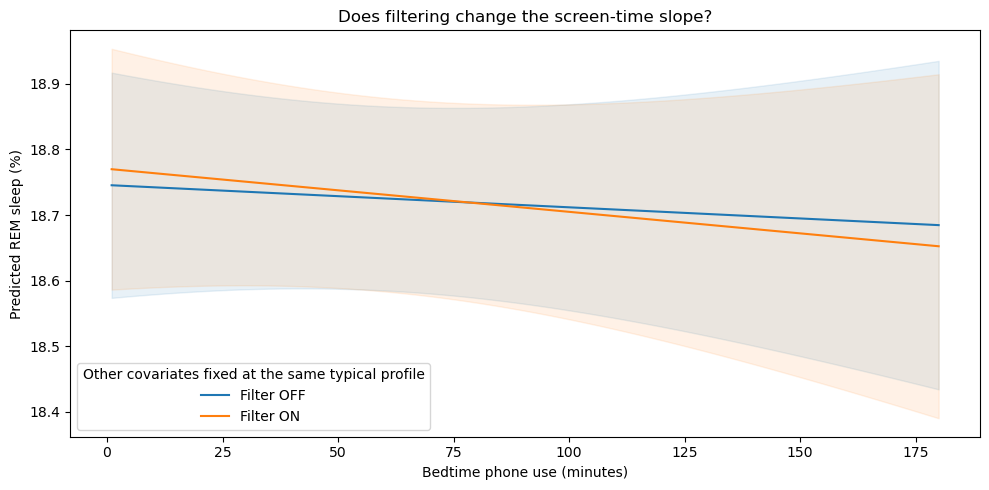

In [42]:
rem_filter_model = smf.ols(rem_main_formula + ' + screen_30:filter_on', data=rem_analysis).fit(cov_type='HC3')
rem_models['filter'] = rem_filter_model
filter_scenarios = {'Filter OFF': {'filter_on': 0}, 'Filter ON': {'filter_on': 1}}
display(rem_slope_table(rem_filter_model, filter_scenarios).round(4))
filter_difference = rem_contrast(rem_filter_model,
    rem_slope_vector(rem_filter_model, {'filter_on': 1}) -
    rem_slope_vector(rem_filter_model, {'filter_on': 0}))
display(pd.DataFrame([filter_difference], index=['Slope change: ON minus OFF']).round(4))
display(rem_analysis.assign(long_phone=rem_analysis.screen_30 > 3).groupby('filter_on').agg(
    n=('rem_pct', 'size'), over_90_minutes=('long_phone', 'sum')))
rem_interaction_test(rem_filter_model, 'filter')
rem_lines(rem_filter_model, filter_scenarios, 'Does filtering change the screen-time slope?')
rem_interpretations['filter'] = (
    '**Outcome:** Filter ON versus OFF changes the REM association per additional 30 phone '
    'minutes by ' + rem_effect_sentence(filter_difference) + '. A positive difference would '
    'suggest attenuation of a negative screen-time slope; a negative difference would suggest '
    'a larger penalty. This tests screen time × filter, not brightness × filter. '
    'Filter status is binary, and the group counts show how much long-use data support each '
    'comparison. Filter users may differ in unmeasured ways, so the estimate is not a causal benefit.')

**Outcome:** Filter ON versus OFF changes the REM association per additional 30 phone minutes by -0.009 REM percentage points (95% CI -0.084 to +0.065). A positive difference would suggest attenuation of a negative screen-time slope; a negative difference would suggest a larger penalty. This tests screen time × filter, not brightness × filter. Filter status is binary, and the group counts show how much long-use data support each comparison. Filter users may differ in unmeasured ways, so the estimate is not a causal benefit. **Interaction evidence:** p = 0.8038; BH-adjusted p = 0.8909. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

### Screen time × caffeine → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
0 mg after 5 pm,-0.0309,-0.0754,0.0136,0.1740
100 mg after 5 pm,0.0188,-0.0423,0.0799,0.5473
200 mg after 5 pm,0.0684,-0.0581,0.1949,0.2893


,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Slope change per +100 mg evening caffeine,0.0496,-0.0229,0.1221,0.1797


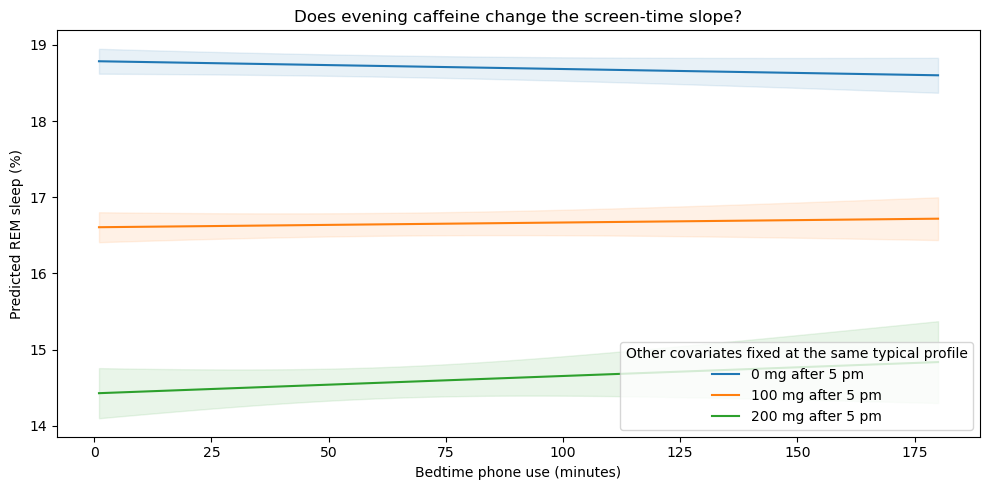

In [23]:
rem_caffeine_model = smf.ols(rem_main_formula + ' + screen_30:caffeine_100', data=rem_analysis).fit(cov_type='HC3')
rem_models['caffeine'] = rem_caffeine_model
caffeine_scenarios = {'0 mg after 5 pm': {'caffeine_100': 0},
                      '100 mg after 5 pm': {'caffeine_100': 1},
                      '200 mg after 5 pm': {'caffeine_100': 2}}
display(rem_slope_table(rem_caffeine_model, caffeine_scenarios).round(4))
caffeine_difference = rem_contrast(rem_caffeine_model,
    rem_slope_vector(rem_caffeine_model, {'caffeine_100': 1}) -
    rem_slope_vector(rem_caffeine_model, {'caffeine_100': 0}))
display(pd.DataFrame([caffeine_difference], index=['Slope change per +100 mg evening caffeine']).round(4))
rem_interaction_test(rem_caffeine_model, 'caffeine')
rem_lines(rem_caffeine_model, caffeine_scenarios, 'Does evening caffeine change the screen-time slope?')
rem_interpretations['caffeine'] = (
    '**Outcome:** An additional 100 mg of caffeine after 5 pm changes the REM association '
    'per additional 30 phone minutes by ' + rem_effect_sentence(caffeine_difference) + '. '
    'A negative difference would indicate a larger screen-time penalty with more caffeine. '
    'Caffeine can have a separate association with REM even if this interaction is weak. '
    'The lines assume a linear change in slope with caffeine dose; the 200 mg scenario may '
    'have less support than the lower-dose scenarios, so it should not be treated as an intervention estimate.')

**Outcome:** An additional 100 mg of caffeine after 5 pm changes the REM association per additional 30 phone minutes by +0.050 REM percentage points (95% CI -0.023 to +0.122). A negative difference would indicate a larger screen-time penalty with more caffeine. Caffeine can have a separate association with REM even if this interaction is weak. The lines assume a linear change in slope with caffeine dose; the 200 mg scenario may have less support than the lower-dose scenarios, so it should not be treated as an intervention estimate. **Interaction evidence:** p = 0.1797; BH-adjusted p = 0.7189. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

### Screen time × app choice → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value,n,over_90_minutes,phone_minutes_min,phone_minutes_max
Instagram / Reddit,-0.0426,-0.1308,0.0455,0.3430,1630,313,2.0,180.0
Streaming (Netflix/Hulu),-0.0391,-0.1383,0.0600,0.4390,1301,203,2.0,180.0
News / Reading,-0.0362,-0.1770,0.1045,0.6139,596,105,5.0,180.0
TikTok / Reels,-0.0159,-0.0861,0.0544,0.6581,2198,430,2.0,180.0
YouTube,0.0141,-0.0653,0.0934,0.7284,1928,333,1.0,180.0
Messaging / Chat,0.0263,-0.0914,0.1441,0.6611,847,161,4.0,180.0


Joint robust F-test of all screen-time-by-app terms: p = 0.8909


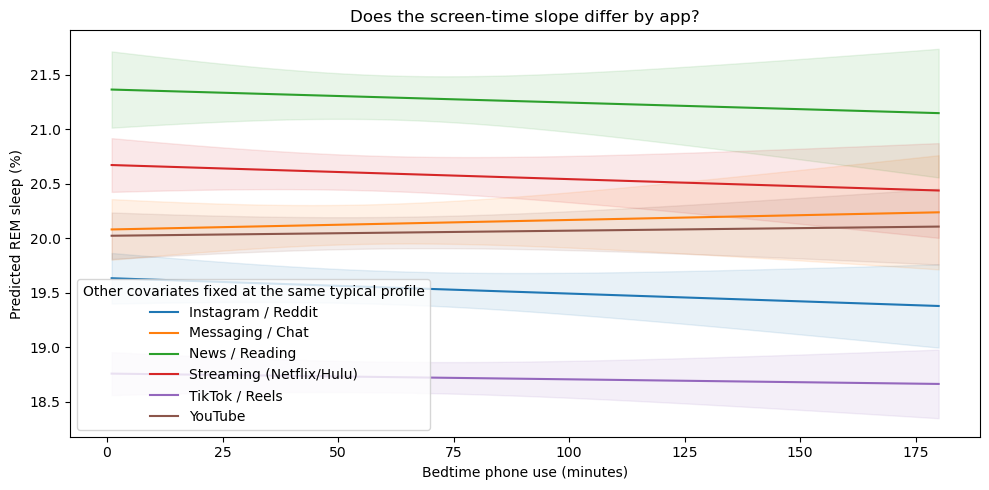

,interaction p-value,adjusted R2,BH-adjusted p-value,change in adjusted R2 vs baseline
brightness,0.70009,0.26835,0.89088,-0.00007
filter,0.80382,0.26834,0.89088,-0.00008
caffeine,0.17972,0.26849,0.71890,0.00007
app,0.89088,0.26814,0.89088,-0.00028


In [24]:
rem_app_model = smf.ols(rem_main_formula + ' + screen_30:C(bedtime_app)', data=rem_analysis).fit(cov_type='HC3')
rem_models['app'] = rem_app_model
app_scenarios = {name: {'bedtime_app': name} for name in sorted(rem_analysis.bedtime_app.unique())}
app_slopes = rem_slope_table(rem_app_model, app_scenarios)
app_support = rem_analysis.assign(long_phone=rem_analysis.screen_30 > 3).groupby('bedtime_app').agg(
    n=('rem_pct', 'size'), over_90_minutes=('long_phone', 'sum'),
    phone_minutes_min=('screen_30', lambda s: s.min() * 30),
    phone_minutes_max=('screen_30', lambda s: s.max() * 30))
display(app_slopes.join(app_support).sort_values('REM pp per +30 min').round(4))
app_joint_p = rem_interaction_test(rem_app_model, 'app')
print(f'Joint robust F-test of all screen-time-by-app terms: p = {app_joint_p:.4g}')
rem_lines(rem_app_model, app_scenarios, 'Does the screen-time slope differ by app?')
app_steepest = app_slopes['REM pp per +30 min'].idxmin()
app_flattest = app_slopes['REM pp per +30 min'].idxmax()
rem_interpretations['app'] = (
    '**Outcome:** The most negative estimated slope is for **' + app_steepest + '** ('
    + rem_effect_sentence(app_slopes.loc[app_steepest].to_dict()) + '), and the least negative '
    'is for **' + app_flattest + '** (' + rem_effect_sentence(app_slopes.loc[app_flattest].to_dict())
    + f'). The joint test asks whether any app slope differs (p = {app_joint_p:.4g}). '
    'Ranking the point estimates alone does not establish that the apps differ: the joint '
    'interaction test, intervals, and sample counts matter. These are broad primary-app '
    'categories, not measurements of content, scrolling intensity, or minutes spent in each app.')

# Correct across the four planned interaction hypotheses, including the joint app test.
rem_interaction_summary = pd.DataFrame(rem_interaction_tests).T
rem_interaction_summary['BH-adjusted p-value'] = multipletests(
    rem_interaction_summary['interaction p-value'], method='fdr_bh')[1]
rem_interaction_summary['change in adjusted R2 vs baseline'] = (
    rem_interaction_summary['adjusted R2'] - rem_baseline.rsquared_adj)
display(rem_interaction_summary.round(5))
for name in rem_interaction_tests:
    p = rem_interaction_summary.loc[name, 'interaction p-value']
    q = rem_interaction_summary.loc[name, 'BH-adjusted p-value']
    conclusion = ('There is evidence of a slope difference after accounting for the four planned tests.'
                  if q < 0.05 else 'There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.')
    rem_interpretations[name] += f' **Interaction evidence:** p = {p:.4g}; BH-adjusted p = {q:.4g}. ' + conclusion
supported = rem_interaction_summary.index[rem_interaction_summary['BH-adjusted p-value'] < 0.05].tolist()
rem_interpretations['summary'] = (
    '**Answer to the question:** ' +
    ('The interactions with evidence of different screen-time slopes are: ' + ', '.join(supported) + '. '
     if supported else 'None of these four interaction tests clearly identifies a behavior that makes the screen-time REM penalty larger or smaller in this dataset. ')
    + 'Distinguish a factor associated with lower REM overall from a factor that changes the penalty '
    'for an extra 30 minutes of screen time. The individual interpretations above quantify those '
    'slope changes. These models impose a constant screen-time slope within each exposure profile; '
    'they do not establish a special threshold for long use. Sparse combinations at the exposure '
    'extremes, nonlinear relationships, unmeasured confounding, and unknown dataset provenance '
    'limit the conclusions. The four-interaction correction does not adjust individual slope '
    'confidence intervals or establish pairwise differences between apps. REM percentage alone '
    'also does not capture the full sleep penalty, such as reduced total sleep or REM minutes.')

**Outcome:** The most negative estimated slope is for **Instagram / Reddit** (-0.043 REM percentage points (95% CI -0.131 to +0.045)), and the least negative is for **Messaging / Chat** (+0.026 REM percentage points (95% CI -0.091 to +0.144)). The joint test asks whether any app slope differs (p = 0.8909). Ranking the point estimates alone does not establish that the apps differ: the joint interaction test, intervals, and sample counts matter. These are broad primary-app categories, not measurements of content, scrolling intensity, or minutes spent in each app. **Interaction evidence:** p = 0.8909; BH-adjusted p = 0.8909. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

**Answer to the question:** None of these four interaction tests clearly identifies a behavior that makes the screen-time REM penalty larger or smaller in this dataset. The baseline screen-time slope is also close to zero, so a REM-percentage penalty is not established in the first place.  The individual interpretations above quantify those slope changes. These models impose a constant screen-time slope within each exposure profile; they do not establish a special threshold for long use. Sparse combinations at the exposure extremes, nonlinear relationships, unmeasured confounding, and unknown dataset provenance limit the conclusions. The four-interaction correction does not adjust individual slope confidence intervals or establish pairwise differences between apps. REM percentage alone also does not capture the full sleep penalty, such as reduced total sleep or REM minutes.
However, while there are no notable major changes, there are minor ones. For example, the increased mg of caffeine caused an increase in slope for more time in REM, the increase in brigthness caused a decrease in slope meaning less time in REM, and turning the blue light filter on brought greater time in REM. They all contribute to better sleep overall. There just isn't one big thing to change.